<a href="https://colab.research.google.com/github/caiohenry-jpg/CalculoNumerico/blob/main/Atividade_2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308

 ATIVIDADE 1 - Estabilidade 
dy       = 0.0005 m
dt_max   = 0.0012499999999999998 s
Caso A: dt=0.001 s  ->  r = 0.40  ->  ESTAVEL
Caso B: dt=0.002 s  ->  r = 0.80  ->  INSTAVEL

RESPOSTA (Atividade 1):
- dy = 0.0005 m
- dt_max = 0.00125 s
- Caso A (dt=0.001 s): r = 0.4 <= 0.5  -> ESTAVEL
- Caso B (dt=0.002 s): r = 0.8 >  0.5  -> INSTAVEL
So de olhar o r ja da pra prever que o Caso B vai dar problema,
mesmo antes de rodar.


===== ATIVIDADE 2 - Deteccao de overflow =====
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add

Tabela dos testes:
tipo numerico  passo de tempo (dt)   r overflow? iteracao da falha
      float32                0.001 0.4       nao                 -
      float32                0.002 0.8       si

/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


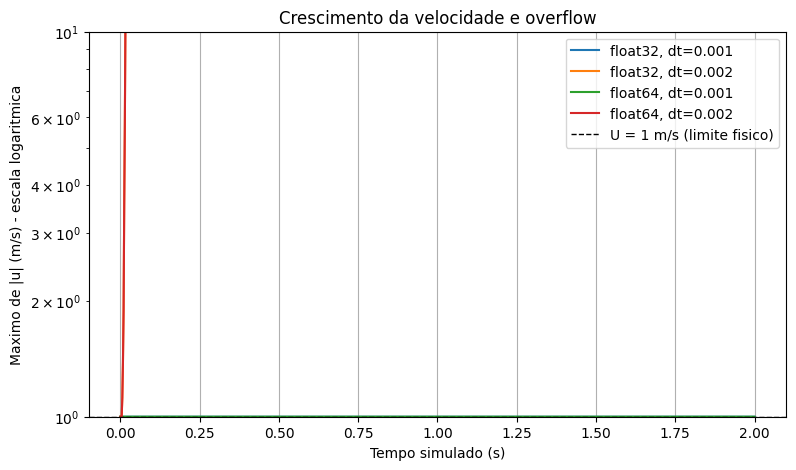


RESPOSTA (Atividade 3):
Fisicamente a velocidade tem que ficar entre 0 e U=1 m/s - a placa
se move a 1 m/s, entao nenhuma parte do fluido pode ir mais rapido.
Nos casos estaveis a curva fica colada em |u|=1. Ja nos instaveis
(r=0.8) a velocidade cresce explosivamente ate 10^38 ou mais,
bilhoes de vezes acima do limite fisico, ate estourar.
Esse crescimento NAO e o fluido de verdade: e o metodo numerico
amplificando pequenas oscilacoes a cada passo. Como r>0.5, o
coeficiente central da atualizacao fica negativo, e o esquema
exagera as diferencas em vez de fazer uma media dos vizinhos.
E um erro do metodo, nao da fisica.


 ATIVIDADE 4 - float32 x float64 
float32 (r=0.8): overflow no passo 121, suporta ate ~3.4e+38
float64 (r=0.8): overflow no passo 917, suporta ate ~1.8e+308

RESPOSTA (Atividade 4):
NAO, trocar o tipo numerico nao elimina a instabilidade. Nos dois
casos com r=0.8 a solucao cresce sem limite - a diferenca e so
QUANDO o numero fica grande demais pra caber:
  - float32 g

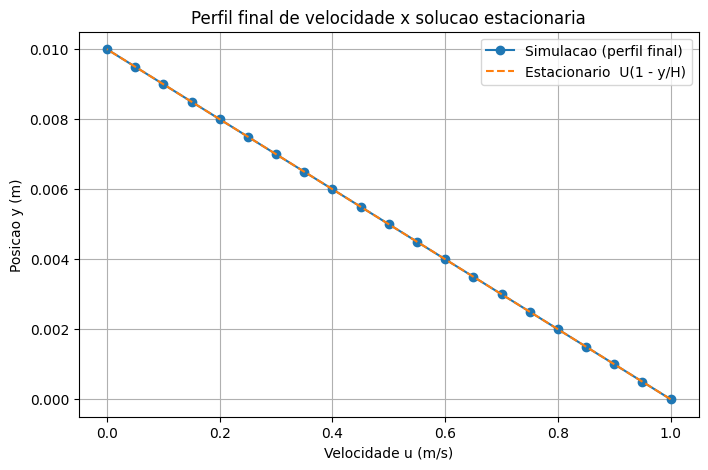


RESPOSTA (Atividade 6):
As duas curvas ficaram praticamente em cima uma da outra, com erro
maximo E_inf ~ 3e-15 m/s (basicamente zero, dentro do arredondamento
da maquina). O tempo simulado FOI suficiente pra alcancar o regime
estacionario: o tempo caracteristico da difusao e da ordem de
H^2/nu = (0.01)^2/1e-4 = 1 s, e simulei 4 s (bem mais que 1 s),
entao o transiente ja acabou. Se simulasse um tempo curto (menos de
~1 s), o perfil ainda estaria "no meio do caminho" e o E_inf seria
maior por causa do transiente nao concluido.


 ATIVIDADE 7 - Conclusao 

Tudo gira em torno de r = nu*dt/dy^2, que precisa ser <= 0.5:
1) Passo de tempo: aumentar dt aumenta r. Passou de 0.5, instabiliza.
2) Refino da malha: mais pontos -> dy menor. Como r depende de dy^2,
   um dy menor faz r crescer bastante - refinar a malha sem reduzir
   o dt tambem joga r acima de 0.5.
3) Instabilidade: com r>0.5 o metodo amplifica oscilacoes e a
   velocidade cresce exponencialmente (nada fisico).
4) Overflow: e a 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CALCULO NUMERICO - ATIVIDADE PRATICA II
# Aluno: Caio Henry - RA:180374

# Dados: H=0.01 m | nu=1e-4 m^2/s | 21 pontos | U=1 m/s


# Constantes do problema
H = 0.01      # distancia entre as placas (m)
nu = 1e-4     # viscosidade cinematica (m^2/s)
U = 1.0       # velocidade da placa movel (m/s)

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)



# ATIVIDADE 1 - Verificacao da estabilidade

# O metodo (Euler explicito no tempo + diferencas centrais no espaco)
# so e estavel quando  r = nu*dt/dy^2 <= 0.5.
# O limite do passo de tempo sai disso: dt_max = dy^2 / (2*nu).
# --------------------------------------------------------------
print("\n ATIVIDADE 1 - Estabilidade ")
dy = H / (21 - 1)              # espacamento entre pontos
dt_max = dy**2 / (2 * nu)      # limite de estabilidade

print(f"dy       = {dy} m")
print(f"dt_max   = {dt_max} s")

def calcular_r(dt, dy):
    return nu * dt / dy**2

for nome, dt in [("Caso A", 0.001), ("Caso B", 0.002)]:
    r = calcular_r(dt, dy)
    estavel = "ESTAVEL" if r <= 0.5 else "INSTAVEL"
    print(f"{nome}: dt={dt} s  ->  r = {r:.2f}  ->  {estavel}")

print("""
RESPOSTA (Atividade 1):
- dy = 0.0005 m
- dt_max = 0.00125 s
- Caso A (dt=0.001 s): r = 0.4 <= 0.5  -> ESTAVEL
- Caso B (dt=0.002 s): r = 0.8 >  0.5  -> INSTAVEL
So de olhar o r ja da pra prever que o Caso B vai dar problema,
mesmo antes de rodar.
""")



# Funcao de simulacao (detecta overflow)

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )
            except FloatingPointError as erro:
                falha = passo
                print(f"dt={dt}, {tipo.__name__}: falha no passo {passo}, "
                      f"t={passo * dt:.4f} s - {erro}")
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")

    return {"y": y, "u": u, "tempos": tempos, "maximos": maximos,
            "r": float(r), "falha": falha}


# ATIVIDADE 2 - Deteccao de overflow (4 testes)

print("\n===== ATIVIDADE 2 - Deteccao de overflow =====")
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

# Tabela dos testes
linhas = []
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        res = resultados[f"{tipo.__name__}, dt={dt}"]
        teve = res["falha"] is not None
        linhas.append({
            "tipo numerico": tipo.__name__,
            "passo de tempo (dt)": dt,
            "r": round(res["r"], 2),
            "overflow?": "sim" if teve else "nao",
            "iteracao da falha": res["falha"] if teve else "-",
        })

tabela = pd.DataFrame(linhas)
print("\nTabela dos testes:")
print(tabela.to_string(index=False))

print("""
RESPOSTA (Atividade 2):
So os casos com dt=0.002 (onde r=0.8 > 0.5) deram overflow -
exatamente os que classifiquei como instaveis na Atividade 1.
Os casos com dt=0.001 (r=0.4) rodaram os 2000 passos sem problema.
O float32 estourou muito mais cedo (passo 121) do que o float64
(passo 917), mesmo tendo o mesmo r. Explico na Atividade 4.
""")



# ATIVIDADE 3 - Interpretacao fisica (grafico)

print("\n ATIVIDADE 3 - Grafico do crescimento ")
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(resultado["tempos"], resultado["maximos"], label=nome)
plt.axhline(U, color="k", linestyle="--", linewidth=1, label="U = 1 m/s (limite fisico)")
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

print("""
RESPOSTA (Atividade 3):
Fisicamente a velocidade tem que ficar entre 0 e U=1 m/s - a placa
se move a 1 m/s, entao nenhuma parte do fluido pode ir mais rapido.
Nos casos estaveis a curva fica colada em |u|=1. Ja nos instaveis
(r=0.8) a velocidade cresce explosivamente ate 10^38 ou mais,
bilhoes de vezes acima do limite fisico, ate estourar.
Esse crescimento NAO e o fluido de verdade: e o metodo numerico
amplificando pequenas oscilacoes a cada passo. Como r>0.5, o
coeficiente central da atualizacao fica negativo, e o esquema
exagera as diferencas em vez de fazer uma media dos vizinhos.
E um erro do metodo, nao da fisica.
""")



# ATIVIDADE 4 - Capacidade de representacao (float32 x float64)

print("\n ATIVIDADE 4 - float32 x float64 ")
for tipo in (np.float32, np.float64):
    res = resultados[f"{tipo.__name__}, dt=0.002"]
    print(f"{tipo.__name__} (r=0.8): overflow no passo {res['falha']}, "
          f"suporta ate ~{np.finfo(tipo).max:.1e}")

print("""
RESPOSTA (Atividade 4):
NAO, trocar o tipo numerico nao elimina a instabilidade. Nos dois
casos com r=0.8 a solucao cresce sem limite - a diferenca e so
QUANDO o numero fica grande demais pra caber:
  - float32 guarda ate ~3.4e38  -> estoura cedo (passo 121)
  - float64 guarda ate ~1.8e308 -> aguenta mais (passo 917)
A instabilidade depende do r (do metodo), nao do tipo numerico.
O float64 so ADIA o overflow porque representa numeros maiores.
A solucao ja estava errada muito antes de estourar nos dois casos.
""")



# ATIVIDADE 5 - Refinamento da malha (41 pontos)

print("\n ATIVIDADE 5 - Refino de malha (41 pontos) ")
dy41 = H / (41 - 1)
dt_max41 = dy41**2 / (2 * nu)
print(f"Com 41 pontos:")
print(f"  dy       = {dy41} m")
print(f"  dt_max   = {dt_max41} s")
print(f"  (com 21 pontos era dy=0.0005 m, dt_max=0.00125 s)")
print()

# Teste 1: mantendo dt=0.001 (que era estavel com 21 pontos)
r = calcular_r(0.001, dy41)
print(f"dt=0.001 com 41 pontos -> r = {r:.2f}")
simular(0.001, np.float64, pontos=41)
print()

# Teste 2: escolhendo um dt abaixo do novo limite
dt_novo = 0.0002
r = calcular_r(dt_novo, dy41)
print(f"dt={dt_novo} com 41 pontos -> r = {r:.2f}")
simular(dt_novo, np.float64, pontos=41)

print("""
RESPOSTA (Atividade 5):
Com 41 pontos: dy=0.00025 m (metade) e dt_max=0.0003125 s (caiu
pra ~1/4 do anterior).
Mantendo dt=0.001, agora r=1.6 > 0.5 -> ficou instavel e deu
overflow (passo 426). Ou seja, o dt=0.001 que era estavel com 21
pontos passou a ser instavel ao refinar a malha.
Motivo: dt_max depende de dy^2. Dobrando os pontos, dy cai pela
metade e dt_max cai pra um quarto. Nao da pra refinar a malha e
manter o mesmo passo de tempo.
Com dt=0.0002 (abaixo do novo dt_max), r=0.32 <= 0.5 -> volta a
ser estavel e roda sem overflow.
""")


# ATIVIDADE 6 - Verificacao do perfil de velocidade

print("\n ATIVIDADE 6 - Perfil estacionario ")
# Execucao estavel e longa: dt=0.001 (r=0.4), 4000 passos = 4 s
res = simular(0.001, np.float64, passos=4000, pontos=21)
y = res["y"]
u_final = res["u"]

# Perfil estacionario teorico
u_est = U * (1 - y / H)

# Erro maximo
E_inf = np.max(np.abs(u_final - u_est))
print(f"Tempo simulado = {4000*0.001} s")
print(f"E_inf = {E_inf:.3e} m/s")

plt.figure(figsize=(8, 5))
plt.plot(u_final, y, "o-", label="Simulacao (perfil final)")
plt.plot(u_est, y, "--", label="Estacionario  U(1 - y/H)")
plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posicao y (m)")
plt.title("Perfil final de velocidade x solucao estacionaria")
plt.grid(True)
plt.legend()
plt.show()

print("""
RESPOSTA (Atividade 6):
As duas curvas ficaram praticamente em cima uma da outra, com erro
maximo E_inf ~ 3e-15 m/s (basicamente zero, dentro do arredondamento
da maquina). O tempo simulado FOI suficiente pra alcancar o regime
estacionario: o tempo caracteristico da difusao e da ordem de
H^2/nu = (0.01)^2/1e-4 = 1 s, e simulei 4 s (bem mais que 1 s),
entao o transiente ja acabou. Se simulasse um tempo curto (menos de
~1 s), o perfil ainda estaria "no meio do caminho" e o E_inf seria
maior por causa do transiente nao concluido.
""")



# ATIVIDADE 7 - Conclusao

print("\n ATIVIDADE 7 - Conclusao ")
print("""
Tudo gira em torno de r = nu*dt/dy^2, que precisa ser <= 0.5:
1) Passo de tempo: aumentar dt aumenta r. Passou de 0.5, instabiliza.
2) Refino da malha: mais pontos -> dy menor. Como r depende de dy^2,
   um dy menor faz r crescer bastante - refinar a malha sem reduzir
   o dt tambem joga r acima de 0.5.
3) Instabilidade: com r>0.5 o metodo amplifica oscilacoes e a
   velocidade cresce exponencialmente (nada fisico).
4) Overflow: e a consequencia final - depois de crescer tanto, o
   numero passa do maior valor que o tipo (float32/float64) guarda
   e estoura. O tipo so muda QUANDO isso acontece, nao SE acontece.

O que corrigiu a causa da falha: reduzir o passo de tempo dt para
manter r <= 0.5 (respeitar dt <= dy^2/(2*nu)). Trocar float32 por
float64 NAO resolve - so adia o overflow. A causa real e o r acima
do limite de estabilidade.
""")